# Load data and train/test split

Everyone uses this. Run these cells first.

In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt

df = pd.read_parquet("combined_preprocessed_weather.parquet")
print(df.shape)


(6898737, 28)


In [61]:
df["IS_HOLIDAY"] = df["IS_HOLIDAY"].astype("category")
df["WX_CODE"] = df["WX_CODE"].astype("int64")
df["WX_CLDC"] = df["WX_CLDC"].astype("int64")
df["WX_RHUM"] = df["WX_RHUM"].astype("int64")

In [62]:
# Drop leakage columns (only known AFTER the flight — kept in preprocessed for EDA only)
postprocessing_cols = [
    "DEP_DELAY",
    "DEP_DEL15",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "OP_UNIQUE_CARRIER",
    "DAY_OF_MONTH" #Potential one hot?
]

X = df.drop(columns=[c for c in postprocessing_cols + ["DELAY_CLASS"] if c in df.columns])
X["DEP_HOUR"] = X["DEP_HOUR"].replace(24, 0)
y = df["DELAY_CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class distribution — train:")
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())


Train: (5518989, 18), Test: (1379748, 18)
Class distribution — train:
DELAY_CLASS
0    0.782692
1    0.168084
2    0.049224
Name: proportion, dtype: float64
DELAY_CLASS
0    0.782692
1    0.168084
2    0.049224
Name: proportion, dtype: float64


In [63]:
X.dtypes

MONTH                   int64
DAY_OF_WEEK             int64
CRS_ELAPSED_TIME      float64
DISTANCE              float64
ORIGIN_STATE           object
DEST_STATE             object
DEP_HOUR                int64
PREV_FLIGHT_DELAY     float64
HAS_PREV_FLIGHT         int64
AIRPORT_TRAFFIC         int64
IS_HOLIDAY           category
WX_TEMP               Float64
WX_RHUM                 int64
WX_PRCP               Float64
WX_WSPD               Float64
WX_PRES               Float64
WX_CLDC                 int64
WX_CODE                 int64
dtype: object

### Data Scaling + One Hot Encoding run THIS

In [64]:
time_vars = ["MONTH", "DAY_OF_WEEK", "DEP_HOUR"]

In [65]:
from sklearn.preprocessing import FunctionTransformer

def circular_transform(X, period):
    X = np.array(X, dtype = float)
    sin_vals = np.sin(2 * np.pi * X / period)
    cos_vals = np.cos(2 * np.pi * X / period)
    return np.column_stack([sin_vals, cos_vals])

hour_transform = FunctionTransformer(circular_transform, kw_args= {"period": 24})
day_transform = FunctionTransformer(circular_transform, kw_args= {"period": 7})
month_transform = FunctionTransformer(circular_transform, kw_args= {"period": 12})

In [66]:
numeric_features = X_train.select_dtypes(include=["int8", "int16", "int32", "int64", "float16", "float32", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns

numeric_features = [feature for feature in numeric_features if feature not in time_vars]
categorical_features = [feature for feature in categorical_features if feature not in time_vars]

In [69]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("dep_hour_circ", hour_transform, ["DEP_HOUR"]),
        ("month_cirl", hour_transform, ["MONTH"]),
        ("day_circ", hour_transform, ["DAY_OF_WEEK"])
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
print(f"Encoded shapes — train: {X_train_preprocessed.shape}, test: {X_test_preprocessed.shape}")


Encoded shapes — train: (5518989, 126), test: (1379748, 126)


# Helper function so everyone reports the same metrics.

In [73]:
CLASS_NAMES = ['No Delay', '15-29 min', '30-59 min', '1-2 hr', '2+ hr']

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"--- {name} ---")
    print(f"Accuracy:      {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (w): {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall (w):    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1 (w):        {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1 (macro):    {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}  ← primary metric for imbalanced multiclass")
    print(f"Precision (m): {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Recall (m):    {recall_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"AUC-ROC:       {roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'):.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cm, cmap="Blues")
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=10)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"),
    }


In [74]:
results = []


**most difficult task -- what features should we use??**

**what features we should drop?? one by one**

**and then, One-hot encoding so that we can add the destination in there**

In [75]:
rng = np.random.RandomState(42)
SAMPLE_IDX = rng.choice(X_train_preprocessed.shape[0], 500_000, replace=False)
X_train_500k = X_train_preprocessed[SAMPLE_IDX]
y_train_500k = y_train.iloc[SAMPLE_IDX]

---
# Sam — Logistic Regression

--- Logistic Regression ---
Accuracy:      0.5979
Precision (w): 0.7398
Recall (w):    0.5979
F1 (w):        0.6518
F1 (macro):    0.3164  ← primary metric for imbalanced multiclass
Precision (m): 0.3105
Recall (m):    0.3706
AUC-ROC:       0.7721

              precision    recall  f1-score   support

    No Delay       0.90      0.69      0.78   1079918
   15-29 min       0.13      0.36      0.19     98631
   30-59 min       0.15      0.17      0.16     90237
      1-2 hr       0.19      0.21      0.20     65499
       2+ hr       0.18      0.43      0.25     45463

    accuracy                           0.60   1379748
   macro avg       0.31      0.37      0.32   1379748
weighted avg       0.74      0.60      0.65   1379748



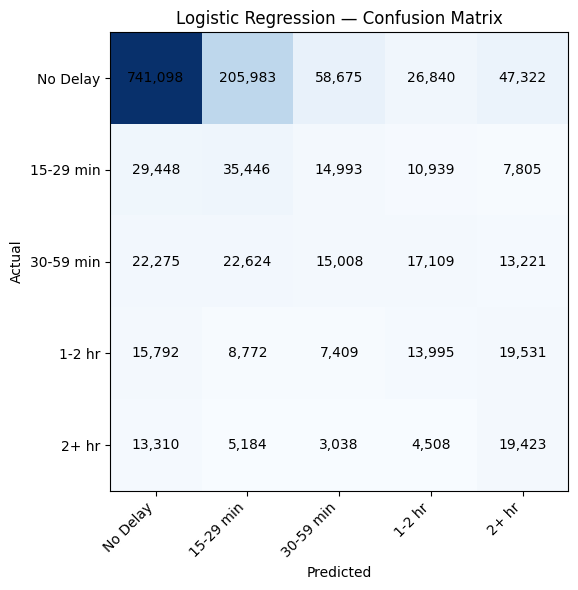

In [9]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Shared 500k sample — same index used by LR, RF, XGBoost for fair comparison
rng = np.random.RandomState(42)
SAMPLE_IDX = rng.choice(X_train_preprocessed.shape[0], 500_000, replace=False)
X_train_500k = X_train_preprocessed[SAMPLE_IDX]
y_train_500k = y_train.iloc[SAMPLE_IDX]

lr_model = LogisticRegression(
    solver="saga",
    max_iter=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_train_500k, y_train_500k)

results.append(evaluate('Logistic Regression', lr_model, X_test_preprocessed, y_test))


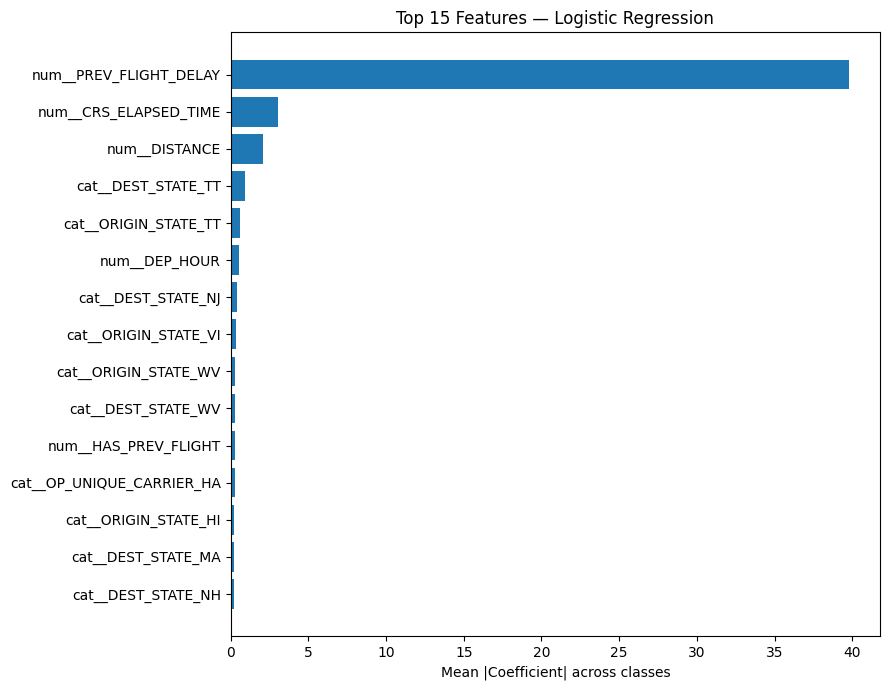

In [10]:
# Feature importance: mean absolute coefficient across classes
feature_names = preprocessor.get_feature_names_out()
mean_abs_coef = np.abs(lr_model.coef_).mean(axis=0)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_abs_coef,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coef_df["feature"], coef_df["importance"], color="#1f77b4")
ax.set_xlabel("Mean |Coefficient| across classes")
ax.set_title("Top 15 Features — Logistic Regression")
plt.tight_layout()
plt.show()


---
# Wahid — Random Forest

In [76]:
from sklearn.ensemble import RandomForestClassifier

# Uses the same 500k sample defined in the Logistic Regression cell
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_500k, y_train_500k)

results.append(evaluate('Random Forest', rf_model, X_test_preprocessed, y_test))


--- Random Forest ---
Accuracy:      0.8075
Precision (w): 0.8067
Recall (w):    0.8075
F1 (w):        0.8065
F1 (macro):    0.6238  ← primary metric for imbalanced multiclass
Precision (m): 0.6456
Recall (m):    0.6094
AUC-ROC:       0.7997



ValueError: Number of classes, 3, does not match size of target_names, 5. Try specifying the labels parameter

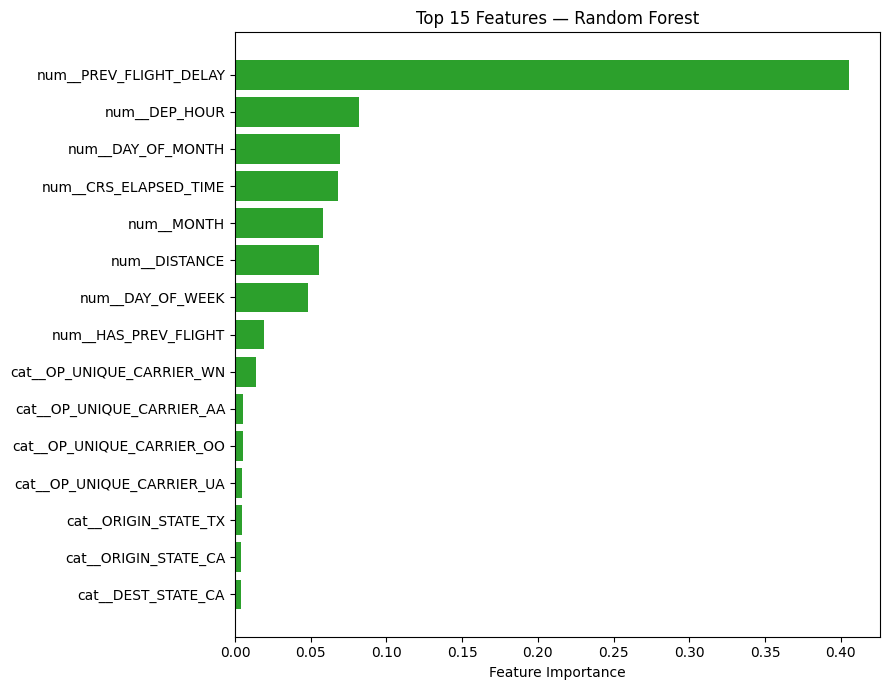

In [12]:
feature_names = preprocessor.get_feature_names_out()
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp_df["feature"], imp_df["importance"], color="#2ca02c")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 15 Features — Random Forest")
plt.tight_layout()
plt.show()


---
# Aryan — XGBoost

--- XGBoost ---
Accuracy:      0.7070
Precision (w): 0.7812
Recall (w):    0.7070
F1 (w):        0.7358
F1 (macro):    0.4410  ← primary metric for imbalanced multiclass
Precision (m): 0.4403
Recall (m):    0.4824
AUC-ROC:       0.8108

              precision    recall  f1-score   support

    No Delay       0.91      0.79      0.85   1079918
   15-29 min       0.21      0.46      0.29     98631
   30-59 min       0.45      0.34      0.38     90237
      1-2 hr       0.42      0.38      0.40     65499
       2+ hr       0.21      0.45      0.28     45463

    accuracy                           0.71   1379748
   macro avg       0.44      0.48      0.44   1379748
weighted avg       0.78      0.71      0.74   1379748



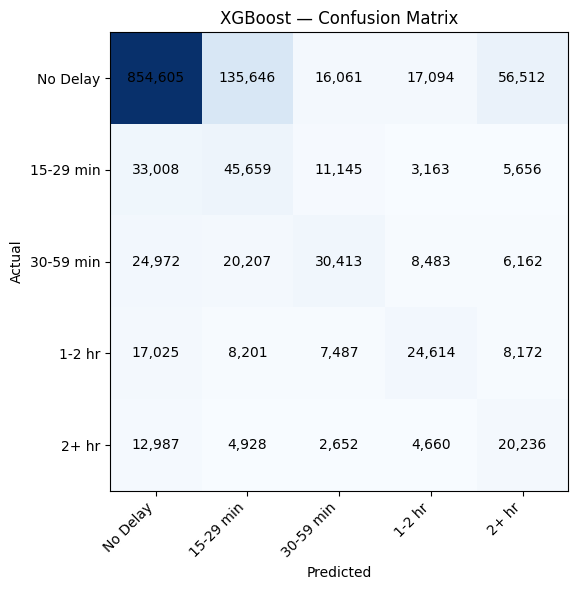

In [13]:
import xgboost as xgb

# Uses the same 500k sample defined in the Logistic Regression cell
X_train_xgb = X_train_500k
X_test_xgb  = X_test_preprocessed
y_train_xgb = y_train_500k.values

# Inverse class frequency weights for imbalance
class_counts = np.bincount(y_train_xgb)
class_weights = len(y_train_xgb) / (len(class_counts) * class_counts)
sample_weights = class_weights[y_train_xgb]

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    max_depth=5,
    learning_rate=0.2,
    n_estimators=100,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
xgb_model.fit(X_train_xgb, y_train_xgb, sample_weight=sample_weights, verbose=False)

results.append(evaluate('XGBoost', xgb_model, X_test_xgb, y_test))

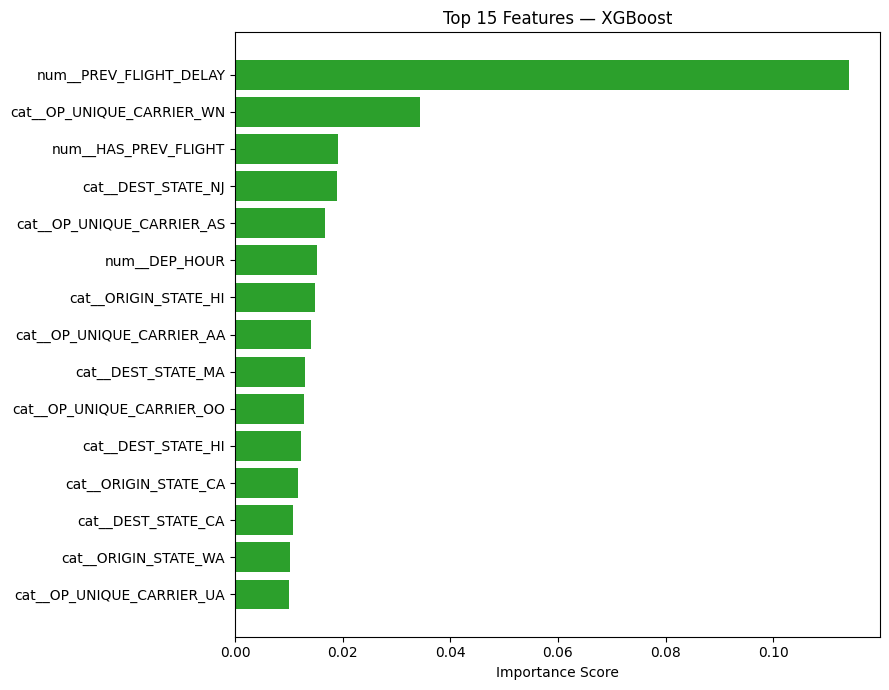

In [14]:
# XGBoost feature importance — use encoded feature names to match the model
importances = xgb_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df["feature"], importance_df["importance"], color="#2ca02c")
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Features — XGBoost")
plt.tight_layout()
plt.show()


---
# Dennis — Naive Bayes

## Naive Bayes

In [15]:
from sklearn.preprocessing import OrdinalEncoder

def pipeline(data, encoder = None):

    cat_cols_idx = []
    for col_idx, col in enumerate(data.columns):
        if col != "DISTANCE":
            cat_cols_idx.append(col_idx)

    if encoder is None:
        encoder = OrdinalEncoder(dtype = int)
        data.iloc[:, cat_cols_idx] = encoder.fit_transform(data.iloc[:, cat_cols_idx])
    else:
        data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])

    data = data.apply(pd.to_numeric)

    return data, encoder


In [16]:
# Load the same preprocessed file (no separate no-leakage parquet exists)
df_nb = pd.read_parquet("combined_preprocessed.parquet")

leak_cols = [
    "DEP_DELAY",
    "ARR_DELAY",
    "DEP_DEL15",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "DIVERTED",
    "DEST_AIRPORT_SEQ_ID",
]
X_nb = df_nb.drop(columns=[c for c in leak_cols + ["DELAY_CLASS"] if c in df_nb.columns])
X_nb["DEP_HOUR"] = X_nb["DEP_HOUR"].replace(24, 0)

y_nb = df_nb["DELAY_CLASS"]

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb,
    y_nb,
    test_size=0.2,
    random_state=42,
    stratify=y_nb,
)


In [17]:
from sklearn.preprocessing import OrdinalEncoder

# MixedNB needs truly continuous cols treated as numeric, not categorical
NUMERIC_COLS = {"DISTANCE", "CRS_ELAPSED_TIME", "PREV_FLIGHT_DELAY"}

encoder = OrdinalEncoder(dtype=int, handle_unknown="use_encoded_value", unknown_value=-1)
cat_cols = [col for col in X_nb.columns if col not in NUMERIC_COLS]
encoder.fit(X_nb[cat_cols])

# Balanced 500k sample (100k per class) — matches sample size used by LR/RF/XGBoost
PER_CLASS = 100_000
min_count = min(y_train_nb.value_counts().min(), PER_CLASS)
X_train_bal = (
    X_train_nb.groupby(y_train_nb, group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)
y_train_bal = (
    y_train_nb.groupby(y_train_nb, group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)

def nb_pipeline(data, encoder):
    data = data.copy()
    cat_cols_idx = [i for i, col in enumerate(data.columns) if col not in NUMERIC_COLS]
    data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])
    return data.apply(pd.to_numeric)

X_train_bal = nb_pipeline(X_train_bal, encoder)
X_test_nb   = nb_pipeline(X_test_nb, encoder)
print(f"NB train size: {len(X_train_bal):,} ({min_count:,} per class)")


/var/folders/wq/cbr397vs4lg_5jhclv7yd5r40000gn/T/ipykernel_65460/2138484206.py:27: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])
/var/folders/wq/cbr397vs4lg_5jhclv7yd5r40000gn/T/ipykernel_65460/2138484206.py:27: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])


NB train size: 500,000 (100,000 per class)


In [18]:
X_train_bal.head()


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,CRS_ELAPSED_TIME,DISTANCE,ORIGIN_STATE,DEST_STATE,DEP_HOUR,PREV_FLIGHT_DELAY,HAS_PREV_FLIGHT
0,3,0,1,12,75.0,293.0,44,44,17,-3.0,1
1,0,2,4,11,198.0,1492.0,5,33,18,-11.0,1
2,7,29,5,5,127.0,855.0,3,15,10,-15.0,1
3,6,18,5,10,208.0,1081.0,13,5,8,-12.0,1
4,11,5,5,10,94.0,404.0,44,15,13,-27.0,1


In [19]:
from mixed_naive_bayes import MixedNB

cat_cols_idx = [i for i, col in enumerate(X_train_bal.columns) if col not in NUMERIC_COLS]

nb_clf = MixedNB(categorical_features=cat_cols_idx)
nb_clf.fit(X_train_bal, y_train_bal)


MixedNB(alpha=0.5, var_smoothing=1e-09)

--- Naive Bayes ---
Accuracy:      0.5931
Precision (w): 0.7506
Recall (w):    0.5931
F1 (w):        0.6505
F1 (macro):    0.3666  ← primary metric for imbalanced multiclass
Precision (m): 0.3913
Recall (m):    0.3964
AUC-ROC:       0.7590

              precision    recall  f1-score   support

    No Delay       0.89      0.66      0.76   1079918
   15-29 min       0.12      0.48      0.19     98631
   30-59 min       0.22      0.20      0.21     90237
      1-2 hr       0.27      0.32      0.30     65499
       2+ hr       0.45      0.32      0.37     45463

    accuracy                           0.59   1379748
   macro avg       0.39      0.40      0.37   1379748
weighted avg       0.75      0.59      0.65   1379748



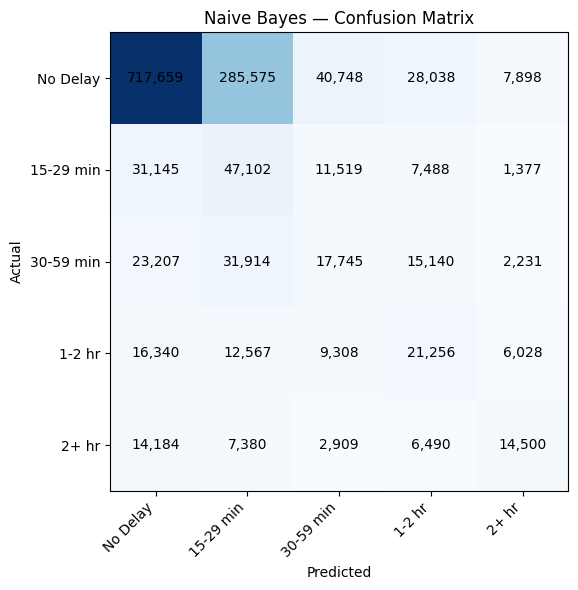

In [20]:
results.append(evaluate(name='Naive Bayes', model=nb_clf, X_test=X_test_nb, y_test=y_test_nb))


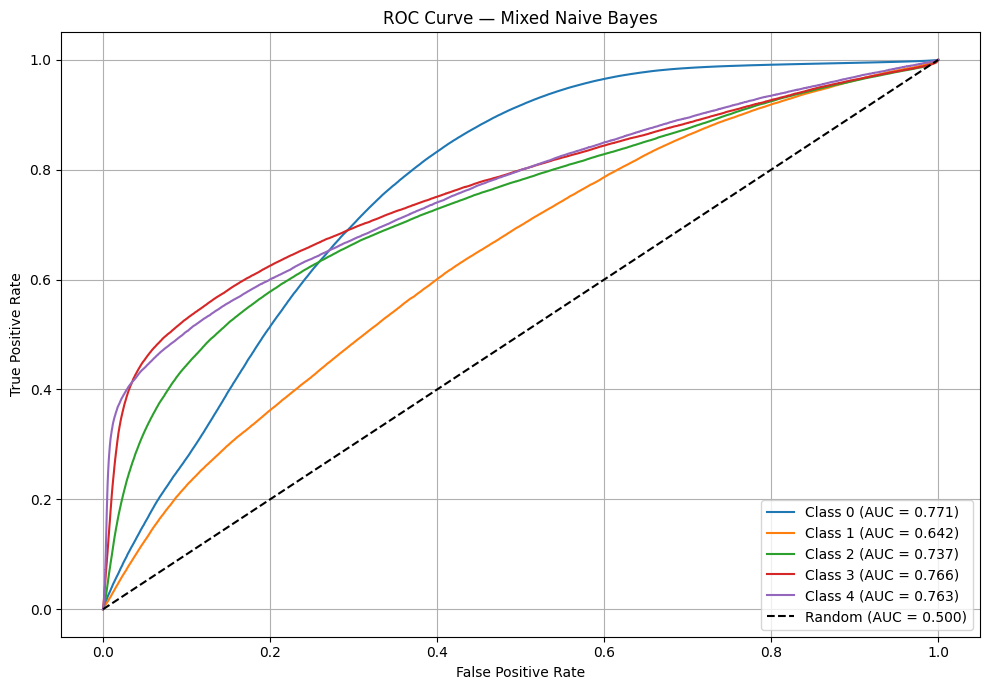

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba = nb_clf.predict_proba(X_test_nb)

classes = np.unique(y_test_nb)
y_test_bin = label_binarize(y_test_nb, classes=classes)

plt.figure(figsize=(10, 7))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Mixed Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


---
# Aryan - RNN
Requires specific version `pip install tensorflow==2.18.0`

In [22]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# Scale X_train and X_test with StandardScaler
scaler = StandardScaler()
X_train_rnn = scaler.fit_transform(X_train_500k)
X_test_rnn = scaler.transform(X_test_preprocessed)

# Reshape to 3D: (samples, 1, features) — RNN expects 3D input
X_train_rnn = X_train_rnn.reshape(X_train_rnn.shape[0], 1, X_train_rnn.shape[1])
X_test_rnn = X_test_rnn.reshape(X_test_rnn.shape[0], 1, X_test_rnn.shape[1])

print(f"RNN train shape: {X_train_rnn.shape}, test shape: {X_test_rnn.shape}")


RNN train shape: (500000, 1, 128), test shape: (1379748, 1, 128)


In [23]:
# Build Sequential: SimpleRNN(64) -> Dropout(0.3) -> Dense(32) -> Dense(5, softmax)
rnn_model = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(1, X_train_rnn.shape[2])),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

# Compile with optimizer='adam', loss='sparse_categorical_crossentropy'
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit with epochs=10, batch_size=1024, validation_split=0.1
rnn_model.fit(
    X_train_rnn,
    y_train_500k.values,
    epochs=30,
    batch_size=1024,
    validation_split=0.1,
    verbose=1
)


/Users/spartan4life/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7621 - loss: 0.8106 - val_accuracy: 0.7966 - val_loss: 0.6817
Epoch 2/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7997 - loss: 0.6852 - val_accuracy: 0.8107 - val_loss: 0.6547
Epoch 3/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8100 - loss: 0.6598 - val_accuracy: 0.8173 - val_loss: 0.6398
Epoch 4/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8141 - loss: 0.6462 - val_accuracy: 0.8200 - val_loss: 0.6314
Epoch 5/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8166 - loss: 0.6376 - val_accuracy: 0.8210 - val_loss: 0.6260
Epoch 6/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8177 - loss: 0.6329 - val_accuracy: 0.8207 - val_loss: 0.6249
Epoch 7/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8185 - loss: 0.6300 - val_accuracy: 0.8214 - val_loss: 0.6223
Epoch 8/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8189 - loss: 0.6284 - val_accuracy: 0.

--- RNN ---
Accuracy:      0.8240
Precision (w): 0.7867
Recall (w):    0.8240
F1 (w):        0.7909
F1 (macro):    0.4719  ← primary metric for imbalanced multiclass
Precision (m): 0.6122
Recall (m):    0.4147
AUC-ROC:       0.8109

              precision    recall  f1-score   support

    No Delay       0.86      0.98      0.91   1079918
   15-29 min       0.46      0.15      0.22     98631
   30-59 min       0.53      0.32      0.40     90237
      1-2 hr       0.59      0.34      0.43     65499
       2+ hr       0.62      0.28      0.39     45463

    accuracy                           0.82   1379748
   macro avg       0.61      0.41      0.47   1379748
weighted avg       0.79      0.82      0.79   1379748



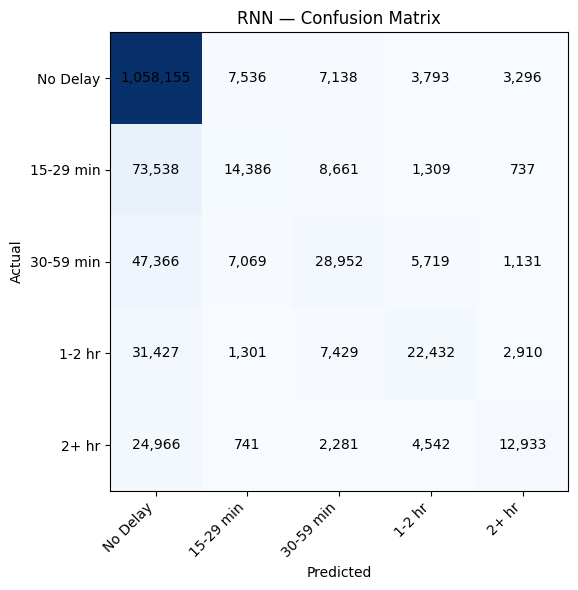

In [ ]:
# Create wrapper to match sklearn interface
class RNNWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        probabilities = self.model.predict(X, verbose=0)
        return probabilities.argmax(axis=1)

    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)

# Get probabilities: y_prob = rnn_model.predict(X_test_rnn)  # shape (N, 5)
# Get predictions: y_pred = y_prob.argmax(axis=1)
# Print weighted metrics (accuracy, precision, recall, F1, AUC-ROC with multi_class='ovr')
# Plot confusion matrix (5x5)
# Append results dict to results list
rnn_wrapper = RNNWrapper(rnn_model)
results.append(evaluate('RNN', rnn_wrapper, X_test_rnn, y_test))


---
# Compare all models

In [25]:
comparison = pd.DataFrame(results).set_index('Model')
comparison.round(4)

,Accuracy,F1 (macro),Precision (macro),Recall (macro),F1 (weighted),AUC-ROC
Model,,,,,,
Logistic Regression,0.5979,0.3164,0.3105,0.3706,0.6518,0.7721
Random Forest,0.7425,0.4656,0.4914,0.4626,0.7564,0.7907
XGBoost,0.7070,0.4410,0.4403,0.4824,0.7358,0.8108
Naive Bayes,0.5931,0.3666,0.3913,0.3964,0.6505,0.7590
RNN,0.8240,0.4719,0.6122,0.4147,0.7909,0.8109


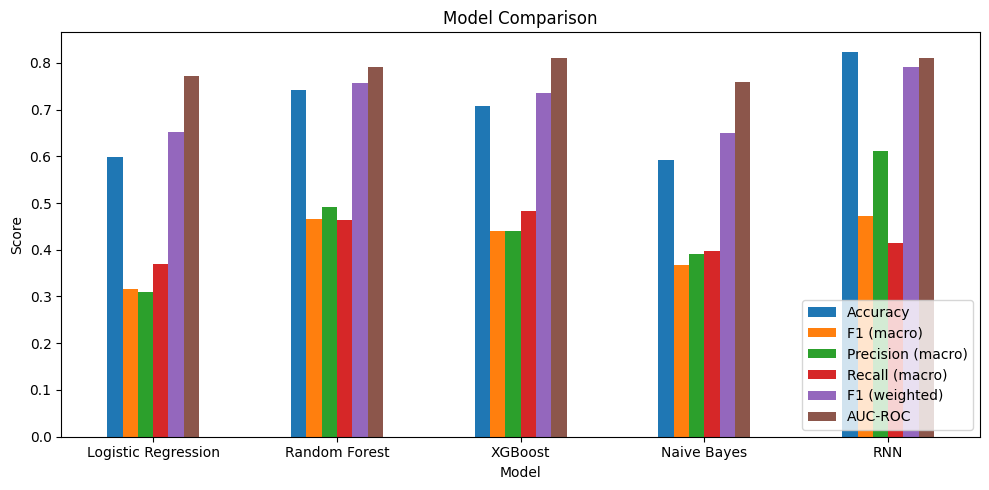

In [26]:
comparison.plot.bar(figsize=(10, 5), title='Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [3]:
pd.read_parquet("combined_preprocessed_weather.parquet")

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEP_DELAY,DEP_DEL15,CRS_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,...,DEP_HOUR,PREV_FLIGHT_DELAY,HAS_PREV_FLIGHT,WX_TEMP,WX_RHUM,WX_PRCP,WX_WSPD,WX_PRES,WX_CLDC,WX_CODE
0,1,1,3,G4,-5.0,0.0,199.0,1334.0,NaN,NaN,...,10,0.0,0,21.1,90,0.0,7.6,1016.0,4,3
1,1,1,3,G4,-3.0,0.0,223.0,1334.0,NaN,NaN,...,14,-32.0,1,0.0,0,0.0,0.0,0.0,0,0
2,1,2,4,G4,-3.0,0.0,148.0,865.0,NaN,NaN,...,6,0.0,0,17.8,84,0.0,9.4,1020.0,0,2
3,1,2,4,G4,-9.0,0.0,147.0,865.0,NaN,NaN,...,9,-21.0,1,0.0,0,0.0,0.0,0.0,0,0
4,1,2,4,G4,-4.0,0.0,120.0,643.0,NaN,NaN,...,12,-21.0,1,16.7,75,0.0,11.2,1021.5,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6898732,12,29,1,B6,31.0,1.0,252.0,1674.0,7.0,0.0,...,20,34.0,1,26.0,65,0.0,13.0,1016.0,2,2
6898733,12,30,2,B6,34.0,1.0,217.0,1237.0,7.0,0.0,...,17,0.0,0,-3.0,41,0.0,39.0,998.0,8,3
6898734,12,30,2,B6,34.0,1.0,171.0,1069.0,12.0,0.0,...,22,17.0,1,16.0,42,0.0,19.0,1017.0,2,2
6898735,12,31,3,B6,-4.0,0.0,190.0,1069.0,NaN,NaN,...,6,0.0,0,-3.0,42,0.0,30.0,1010.0,6,2
